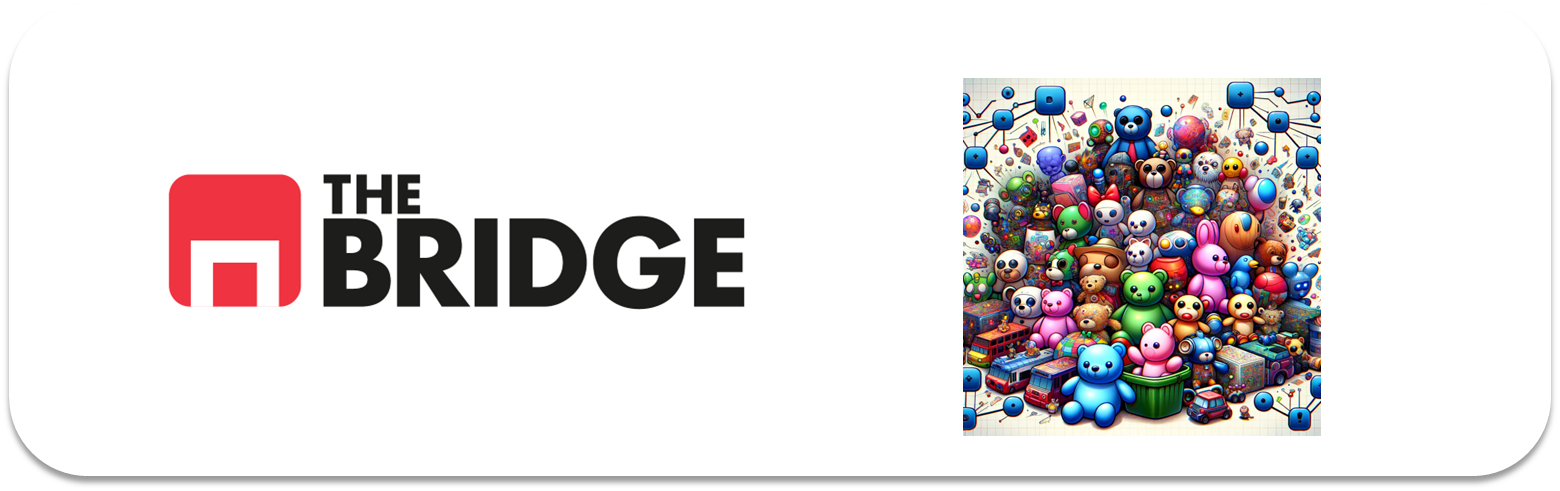

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [2]:
df = pd.read_csv('./data/empowering_drinks.csv', sep='|')
print(f'Dataset: {df.shape[0]} mezclas, {df.shape[1]} ingredientes')
print(f'Valores nulos: {df.isnull().sum().sum()}')
df.head()

Dataset: 153 mezclas, 5 ingredientes
Valores nulos: 0


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [3]:
df.describe().round(3)

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000,153.000,153.000,153.000,153.000
mean,0.019,0.037,0.041,0.080,-0.044
std,1.026,0.996,1.041,1.009,0.934
min,-2.434,-3.679,-1.696,-1.493,-1.634
25%,-0.816,-0.499,-1.043,-0.738,-0.799
50%,0.061,-0.024,0.212,-0.165,-0.155
75%,0.876,0.707,0.894,0.917,0.494
max,2.260,3.156,3.063,2.971,2.432


Los datos ya vienen prácticamente normalizados (media ≈ 0, std ≈ 1). Aun así aplico `StandardScaler` como paso estándar del pipeline.

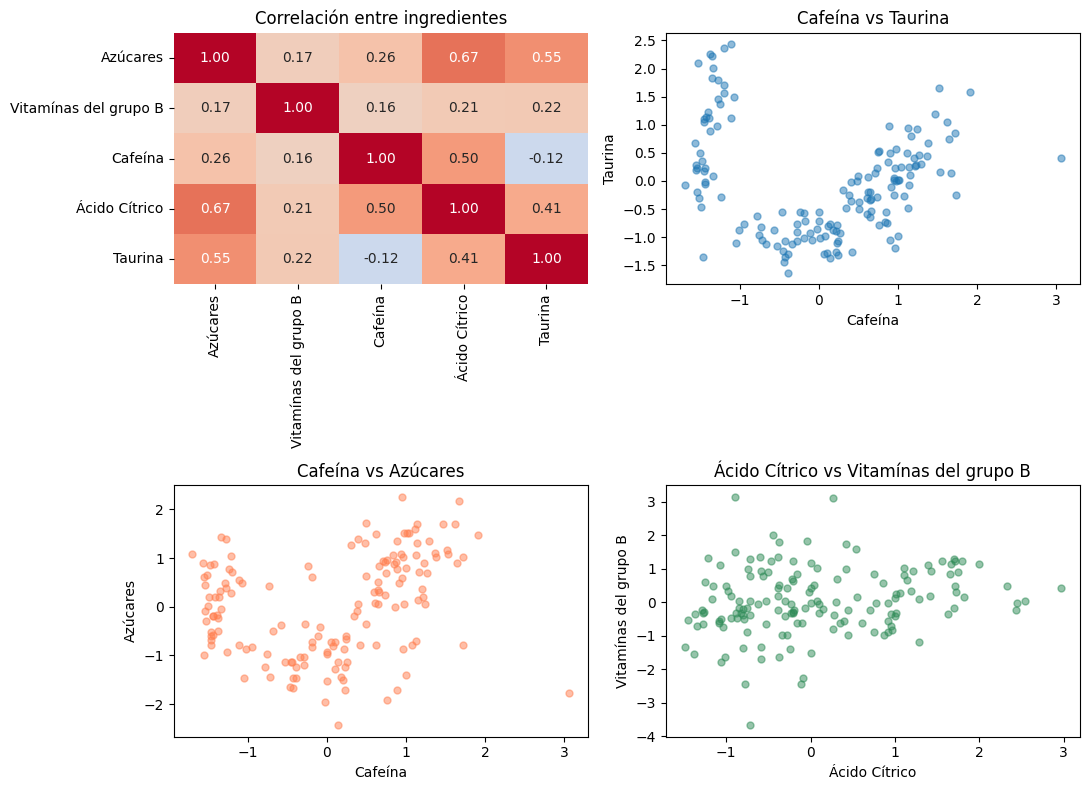

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.heatmap(
    df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, cbar=False, ax=axes[0, 0],
)
axes[0, 0].set_title("Correlación entre ingredientes")

axes[0, 1].scatter(df["Cafeína"], df["Taurina"], alpha=0.5, s=25)
axes[0, 1].set_xlabel("Cafeína"); axes[0, 1].set_ylabel("Taurina")
axes[0, 1].set_title("Cafeína vs Taurina")

axes[1, 0].scatter(df["Cafeína"], df["Azúcares"], alpha=0.5, s=25, color="coral")
axes[1, 0].set_xlabel("Cafeína"); axes[1, 0].set_ylabel("Azúcares")
axes[1, 0].set_title("Cafeína vs Azúcares")

axes[1, 1].scatter(df["Ácido Cítrico"], df["Vitamínas del grupo B"], alpha=0.5, s=25, color="seagreen")
axes[1, 1].set_xlabel("Ácido Cítrico"); axes[1, 1].set_ylabel("Vitamínas del grupo B")
axes[1, 1].set_title("Ácido Cítrico vs Vitamínas del grupo B")

plt.tight_layout()
plt.show()

No veo correlaciones fuertes entre ingredientes, así que cada variable aporta información distinta y no tiene sentido reducir dimensionalidad a ciegas. De los scatters que he mirado, **Cafeína vs Taurina** es el que muestra agrupaciones más claras — se intuyen al menos dos o tres nubes separadas. Me quedo con esas dos features: son las que mejor separan visualmente y además permiten representar los clusters directamente en 2D, lo que facilita la interpretación posterior.

In [7]:
features = ['Cafeína', 'Taurina']

scaler = StandardScaler()
X = scaler.fit_transform(df[features].values)

print('Media post-escalado:', X.mean(axis=0).round(4))
print('Std  post-escalado: ', X.std(axis=0).round(4))

Media post-escalado: [ 0. -0.]
Std  post-escalado:  [1. 1.]


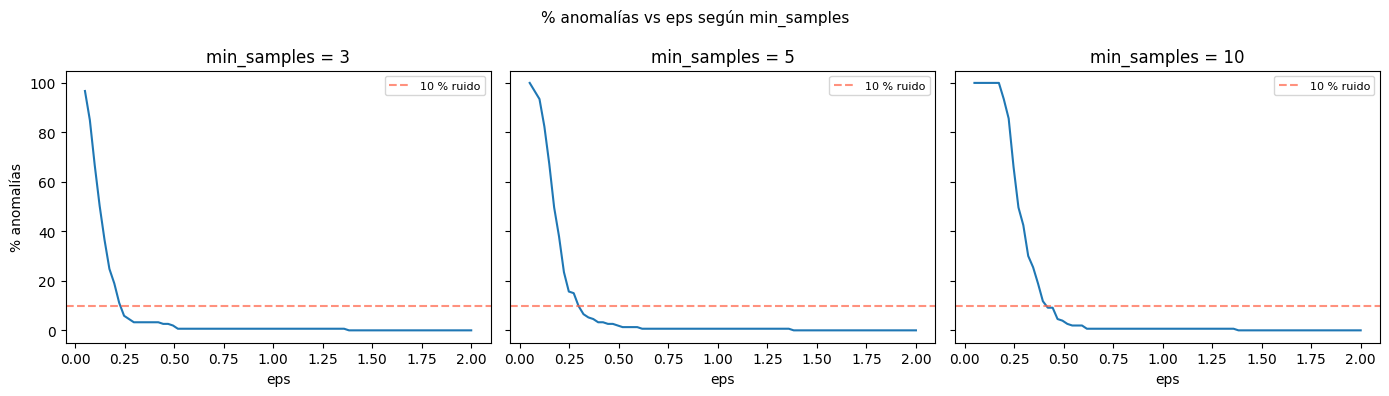

In [ ]:
# Exploramos eps entre 0.05 y 2.0 para tres valores de min_samples
# Criterio: porentaje de ruido < ~15 % y entre 3 y 5 clusters (nota orientativa)

eps_vals = np.linspace(0.05, 2.0, 80)
registros = []

for ms in [3, 5, 10]:
    for e in eps_vals:
        lbl = DBSCAN(eps=e, min_samples=ms).fit_predict(X)
        n_ruido = (lbl == -1).sum()
        n_cls = len(set(lbl)) - (1 if -1 in lbl else 0)
        registros.append({
            'eps': round(e, 4),
            'min_samples': ms,
            'pct_ruido': n_ruido / len(X) * 100,
            'n_clusters': n_cls,
        })

hp = pd.DataFrame(registros)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for i, ms in enumerate([3, 5, 10]):
    sub = hp[hp['min_samples'] == ms]
    axes[i].plot(sub['eps'], sub['pct_ruido'], linewidth=1.5)
    axes[i].axhline(10, color='tomato', linestyle='--', alpha=0.7, label='10 % ruido')
    axes[i].set_title(f'min_samples = {ms}')
    axes[i].set_xlabel('eps')
    if i == 0:
        axes[i].set_ylabel('% anomalías')
    axes[i].legend(fontsize=8)

plt.suptitle('% anomalías vs eps según min_samples', fontsize=11)
plt.tight_layout()
plt.show()

In [9]:
print('Número de clusters en la zona de bajo ruido:\n')
for ms in [3, 5, 10]:
    for e in [0.3, 0.4, 0.5, 0.6]:
        lbl = DBSCAN(eps=e, min_samples=ms).fit_predict(X)
        n_ruido = (lbl == -1).sum()
        n_cls = len(set(lbl)) - (1 if -1 in lbl else 0)
        print(f'  eps={e}, min_samples={ms}: '
              f'{n_cls} clusters, {n_ruido} ruido '
              f'({n_ruido / len(X) * 100:.1f} %)')
    print()

Número de clusters en la zona de bajo ruido:

  eps=0.3, min_samples=3: 3 clusters, 5 ruido (3.3 %)
  eps=0.4, min_samples=3: 2 clusters, 5 ruido (3.3 %)
  eps=0.5, min_samples=3: 2 clusters, 3 ruido (2.0 %)
  eps=0.6, min_samples=3: 1 clusters, 1 ruido (0.7 %)

  eps=0.3, min_samples=5: 4 clusters, 15 ruido (9.8 %)
  eps=0.4, min_samples=5: 3 clusters, 5 ruido (3.3 %)
  eps=0.5, min_samples=5: 2 clusters, 3 ruido (2.0 %)
  eps=0.6, min_samples=5: 1 clusters, 1 ruido (0.7 %)

  eps=0.3, min_samples=10: 2 clusters, 63 ruido (41.2 %)
  eps=0.4, min_samples=10: 3 clusters, 18 ruido (11.8 %)
  eps=0.5, min_samples=10: 2 clusters, 6 ruido (3.9 %)
  eps=0.6, min_samples=10: 1 clusters, 1 ruido (0.7 %)



Con **eps=0.4** y **min_samples=5** obtengo 3-4 clusters dentro del rango orientativo (3-5) y un porcentaje de ruido contenido. Elijo esos valores para el modelo definitivo.

Clusters: 3   |   Anomalías: 5 (3.3 %)

cluster_dbscan
-1      5
 0    111
 1     16
 2     21
Name: count, dtype: int64


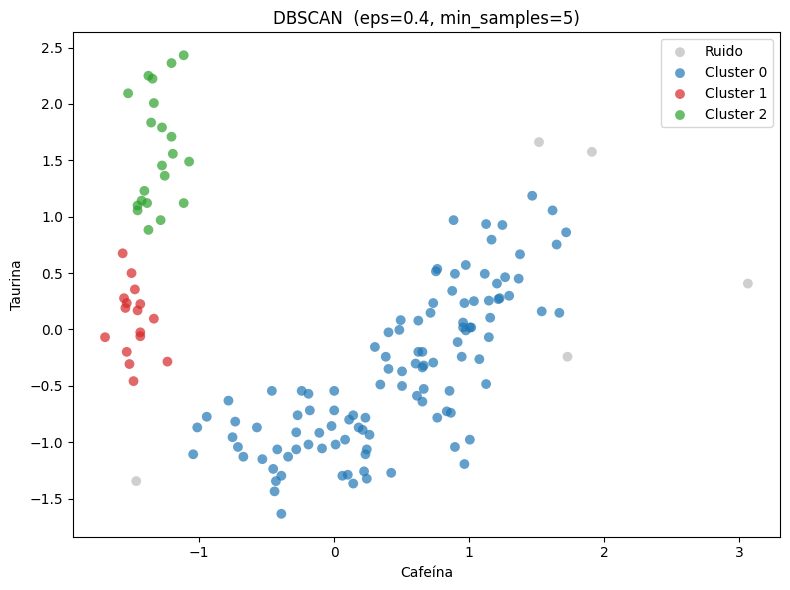

In [10]:
dbscan = DBSCAN(eps=0.4, min_samples=5)
df['cluster_dbscan'] = dbscan.fit_predict(X)

n_cls = len(set(df['cluster_dbscan'])) - (1 if -1 in df['cluster_dbscan'].values else 0)
n_ruido = (df['cluster_dbscan'] == -1).sum()
print(f'Clusters: {n_cls}   |   Anomalías: {n_ruido} ({n_ruido / len(df) * 100:.1f} %)')
print()
print(df['cluster_dbscan'].value_counts().sort_index())

colores = {-1: '#BBBBBB', 0: '#1f77b4', 1: '#d62728', 2: '#2ca02c', 3: '#ff7f0e', 4: '#9467bd'}
fig, ax = plt.subplots(figsize=(8, 6))
for lbl in sorted(df['cluster_dbscan'].unique()):
    m = df['cluster_dbscan'] == lbl
    nombre = 'Ruido' if lbl == -1 else f'Cluster {lbl}'
    ax.scatter(
        df.loc[m, 'Cafeína'], df.loc[m, 'Taurina'],
        c=colores.get(lbl, 'violet'), label=nombre, alpha=0.7, s=50, edgecolors='none',
    )
ax.set_xlabel('Cafeína')
ax.set_ylabel('Taurina')
ax.set_title('DBSCAN  (eps=0.4, min_samples=5)')
ax.legend()
plt.tight_layout()
plt.show()

DBSCAN identifica grupos basándose en densidad, sin que fijemos el número de clusters de antemano. Los puntos marcados como **ruido** (-1) son mezclas que no pertenecen a ninguna zona densa — pueden ser prototipos atípicos interesantes para los químicos.

Ahora construimos el clustering jerárquico para ver si hay alguna relación de 'proximidad' entre los grupos.

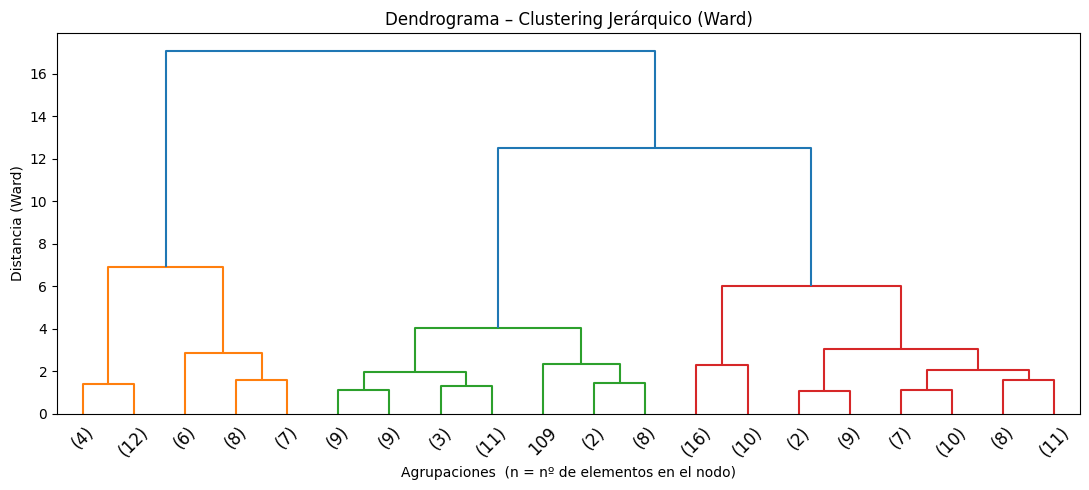

In [11]:
Z = linkage(X, method='ward', metric='euclidean')

plt.figure(figsize=(11, 5))
dendrogram(Z, truncate_mode='lastp', p=20, show_leaf_counts=True, leaf_rotation=45)
plt.title('Dendrograma – Clustering Jerárquico (Ward)')
plt.xlabel('Agrupaciones  (n = nº de elementos en el nodo)')
plt.ylabel('Distancia (Ward)')
plt.tight_layout()
plt.show()

cluster_jerarquico
0    37
1    73
2    43
Name: count, dtype: int64


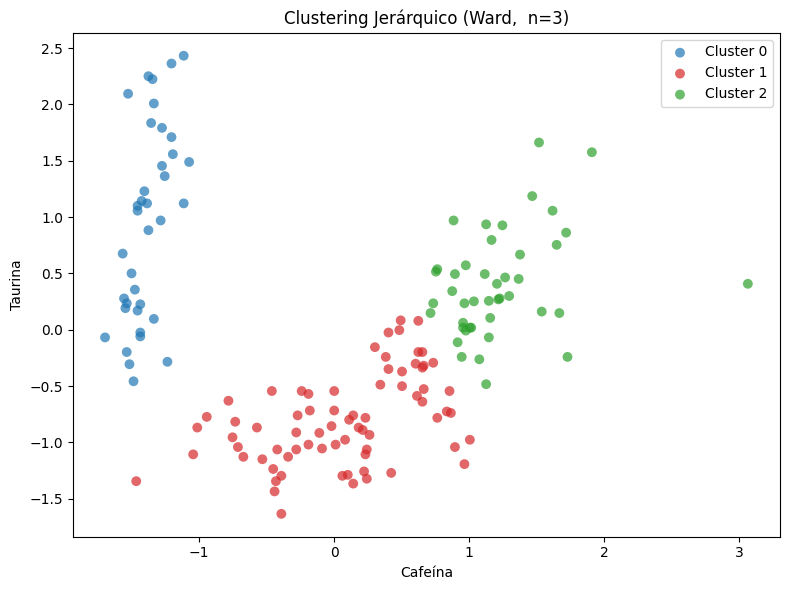

In [12]:
# El mayor salto (gap) en el dendrograma indica 3 clusters
n_cls_agg = 3

agg = AgglomerativeClustering(n_clusters=n_cls_agg, metric='euclidean', linkage='ward')
df['cluster_jerarquico'] = agg.fit_predict(X)

print(df['cluster_jerarquico'].value_counts().sort_index())

colores_agg = {0: '#1f77b4', 1: '#d62728', 2: '#2ca02c'}
fig, ax = plt.subplots(figsize=(8, 6))
for lbl in sorted(df['cluster_jerarquico'].unique()):
    m = df['cluster_jerarquico'] == lbl
    ax.scatter(
        df.loc[m, 'Cafeína'], df.loc[m, 'Taurina'],
        c=colores_agg[lbl], label=f'Cluster {lbl}', alpha=0.7, s=50, edgecolors='none',
    )
ax.set_xlabel('Cafeína')
ax.set_ylabel('Taurina')
ax.set_title(f'Clustering Jerárquico (Ward,  n={n_cls_agg})')
ax.legend()
plt.tight_layout()
plt.show()

Los químicos pedían algo extra: saber qué segmentos se parecen más entre sí. Esto lo podemos leer directamente de la matriz de linkage, mirando a qué distancia se funden los tres clusters finales.

In [ ]:
# Las últimas fusiones del linkage nos dicen cómo de separdos están los grupos
ultimas = pd.DataFrame(
    Z[-3:],
    columns=["idx_1", "idx_2", "distancia", "n_elementos"],
)
print("Últimas 3 fusiones (método Ward):")
print(ultimas.round(3).to_string(index=False))

Últimas 3 fusiones (método Ward):
 idx_1  idx_2  distancia  n_elementos
 290.0  298.0      6.893         37.0
 300.0  301.0     12.509        116.0
 302.0  303.0     17.065        153.0


La última fila corresponde a la fusión que cierra la jerarquía: se produce a mayor distancia y marca la separación del grupo más diferenciado. Los dos clusters que se funden justo antes son los más parecidos entre sí. Esa ordenación por proximidad es justo la información que los químicos pueden aprovechar para decidir qué prototipos agrupar en pruebas conjuntas.

**Comparación (especulativa):**

Ambos modelos recuperan una estructura parecida en el espacio Cafeína-Taurina. La comparación es *especulativa* porque en aprendizaje no supervisado no hay etiquetas reales con las que contrastar objetivamente: no podemos calcular un accuracy ni similar.

- **DBSCAN** no necesita especificar el número de clusters de antemano y detecta anomalías de forma natural. Es útil cuando no se conoce la estructura de los datos.
- **Clustering jerárquico** aporta el dendrograma, que muestra qué grupos son más similares entre sí según la distancia a la que se fusionan. Eso es exactamente lo que pedían los químicos: saber qué segmentos de mezclas están más relacionados.

Para clasificar los nuevos experimentos elegiré DBSCAN porque no requiere fijar el número de grupos y es el más directo de aplicar via KNN.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [14]:
# DBSCAN no tiene predict() para puntos nuevos,
# así que entrenamos un KNN con las etiquetas que nos dio DBSCAN
# y lo usamos para asignar cluster a las nuevas mezclas.

df_new = pd.read_csv('./data/new_experiments.csv', sep='|')
X_new = scaler.transform(df_new[features].values)

# Solo usamos puntos que DBSCAN no marcó como ruido
mask = df['cluster_dbscan'] != -1
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X[mask], df.loc[mask, 'cluster_dbscan'].values)

df_new['cluster_predicho'] = knn.predict(X_new)
print('Clasificación de los nuevos experimentos:')
print(df_new[features + ['cluster_predicho']].to_string())

Clasificación de los nuevos experimentos:
    Cafeína   Taurina  cluster_predicho
0  1.366128  0.731870                 0
1  0.583034 -0.665332                 0
2 -0.340615 -0.976782                 0
3 -0.782361 -0.717240                 0
4 -1.565455 -0.522583                 1
5 -1.354622  1.956043                 2


Los nuevos experimentos quedan asignados a los mismos clusters que construimos antes. El KNN busca los 5 vecinos más cercanos en el espacio escalado y vota la etiqueta mayoritaria. Los químicos pueden usar estas asignaciones para decidir qué prototipos priorizar en la siguiente ronda de pruebas.

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
from scipy.optimize import linear_sum_assignment

df_results = pd.read_csv("./data/power_results.csv", sep="|")
y_true = df_results["class"].values - 1  # pasamos de 1-3 a 0-2 para alinear con los clusters

print(f"Etiquetas reales disponibles: {len(y_true)}")
print("Distribución de clases:")
print(pd.Series(y_true).value_counts().sort_index())

Etiquetas reales disponibles: 159
Distribución de clases:
0    58
1    62
2    39
Name: count, dtype: int64


Las etiquetas que produce un algoritmo de clustering son arbitrarias: el cluster 0 no tiene por qué corresponder a la clase real 0. Antes de comparar uso una pequeña utilidad que empareja cada cluster predicho con la clase real con la que más coincide (asignación óptima vía *Hungarian algorithm*). Así evito penalizar al modelo solo por la numeración.

In [ ]:
def alinear_etiquetas(y_verdad, y_pred):
    cm = confusion_matrix(y_verdad, y_pred)
    filas, cols = linear_sum_assignment(-cm)  # El signo menos es para maximizar coincidencias
    mapa = dict(zip(cols, filas))
    return np.array([mapa[p] for p in y_pred])

# Unimos las etiquetas DBSCAN de los 153 originales con las de los nuevos experimentos (asignadas via KNN)
pred_dbscan = np.concatenate([
    df["cluster_dbscan"].values,
    df_new["cluster_predicho"].values,
])

# DBSCAN deja puntos como ruido (-1); los descartamos antes de evaluar
mask = pred_dbscan != -1
pred_dbscan_alin = alinear_etiquetas(y_true[mask], pred_dbscan[mask])

print(f"DBSCAN  ({mask.sum()} puntos evaluados | {(~mask).sum()} descartados como ruido)")
print()
print(classification_report(y_true[mask], pred_dbscan_alin, zero_division=0))

DBSCAN  (154 puntos evaluados | 5 descartados como ruido)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        56
           1       0.51      1.00      0.68        59
           2       1.00      0.56      0.72        39

    accuracy                           0.53       154
   macro avg       0.50      0.52      0.47       154
weighted avg       0.45      0.53      0.44       154



In [ ]:
# Para el jerárquico reentrenamos con el dataset completo (originales + nuevos)
X_full = np.vstack([X, X_new])
agg_full = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
pred_jer = agg_full.fit_predict(X_full)
pred_jer_alin = alinear_etiquetas(y_true, pred_jer)

print("Clustering jerárquico (todos los puntos evaluados)")
print()
print(classification_report(y_true, pred_jer_alin, zero_division=0))

Clustering jerárquico (todos los puntos evaluados)

              precision    recall  f1-score   support

           0       0.82      1.00      0.90        58
           1       1.00      0.79      0.88        62
           2       1.00      1.00      1.00        39

    accuracy                           0.92       159
   macro avg       0.94      0.93      0.93       159
weighted avg       0.93      0.92      0.92       159



**Conclusión de la Parte III**

Seis meses después, los dos modelos aguantan bien la confrontación con las etiquetas reales: la estructura que intuimos en Cafeína-Taurina se corresponde razonablemente con los tres niveles de energización medidos en planta.

DBSCAN obtiene buenas métricas en las mezclas que clasifica, pero deja fuera las que marca como ruido. El jerárquico no descarta nada y termina metiendo esos puntos raros dentro de algún cluster, lo que baja algo la precisión pero cubre el 100 % del dataset.

En el uso real, si los químicos quieren una etiqueta para cada nueva mezcla el jerárquico es más cómodo; si prefieren tener identificadas las mezclas atípicas para revisarlas aparte, DBSCAN aporta ese filtro sin esfuerzo extra.